In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Create dataset
dataset_dict = {
   'Outlook': ['sunny', 'sunny', 'overcast', 'rain', 'rain', 'rain', 'overcast', 
               'sunny', 'sunny', 'rain', 'sunny', 'overcast', 'overcast', 'rain',
               'sunny', 'overcast', 'rain', 'sunny', 'sunny', 'rain', 'overcast',
               'rain', 'sunny', 'overcast', 'sunny', 'overcast', 'rain', 'overcast'],
   'Temp.': [85.0, 80.0, 83.0, 70.0, 68.0, 65.0, 64.0, 72.0, 69.0, 75.0, 75.0,
             72.0, 81.0, 71.0, 81.0, 74.0, 76.0, 78.0, 82.0, 67.0, 85.0, 73.0,
             88.0, 77.0, 79.0, 80.0, 66.0, 84.0],
   'Humid.': [85.0, 90.0, 78.0, 96.0, 80.0, 70.0, 65.0, 95.0, 70.0, 80.0, 70.0,
              90.0, 75.0, 80.0, 88.0, 92.0, 85.0, 75.0, 92.0, 90.0, 85.0, 88.0,
              65.0, 70.0, 60.0, 95.0, 70.0, 78.0],
   'Wind': [False, True, False, False, False, True, True, False, False, False, True,
            True, False, True, True, False, False, True, False, True, True, False,
            True, False, False, True, False, False],
   'Num_Players': [52, 39, 43, 37, 28, 19, 43, 47, 56, 33, 49, 23, 42, 13, 33, 29,
                   25, 51, 41, 14, 34, 29, 49, 36, 57, 21, 23, 41]
}

# Prepare data
df = pd.DataFrame(dataset_dict)
df = pd.get_dummies(df, columns=['Outlook'], prefix='', prefix_sep='')
df['Wind'] = df['Wind'].astype(int)

# Split features and target
X, y = df.drop('Num_Players', axis=1), df['Num_Players']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

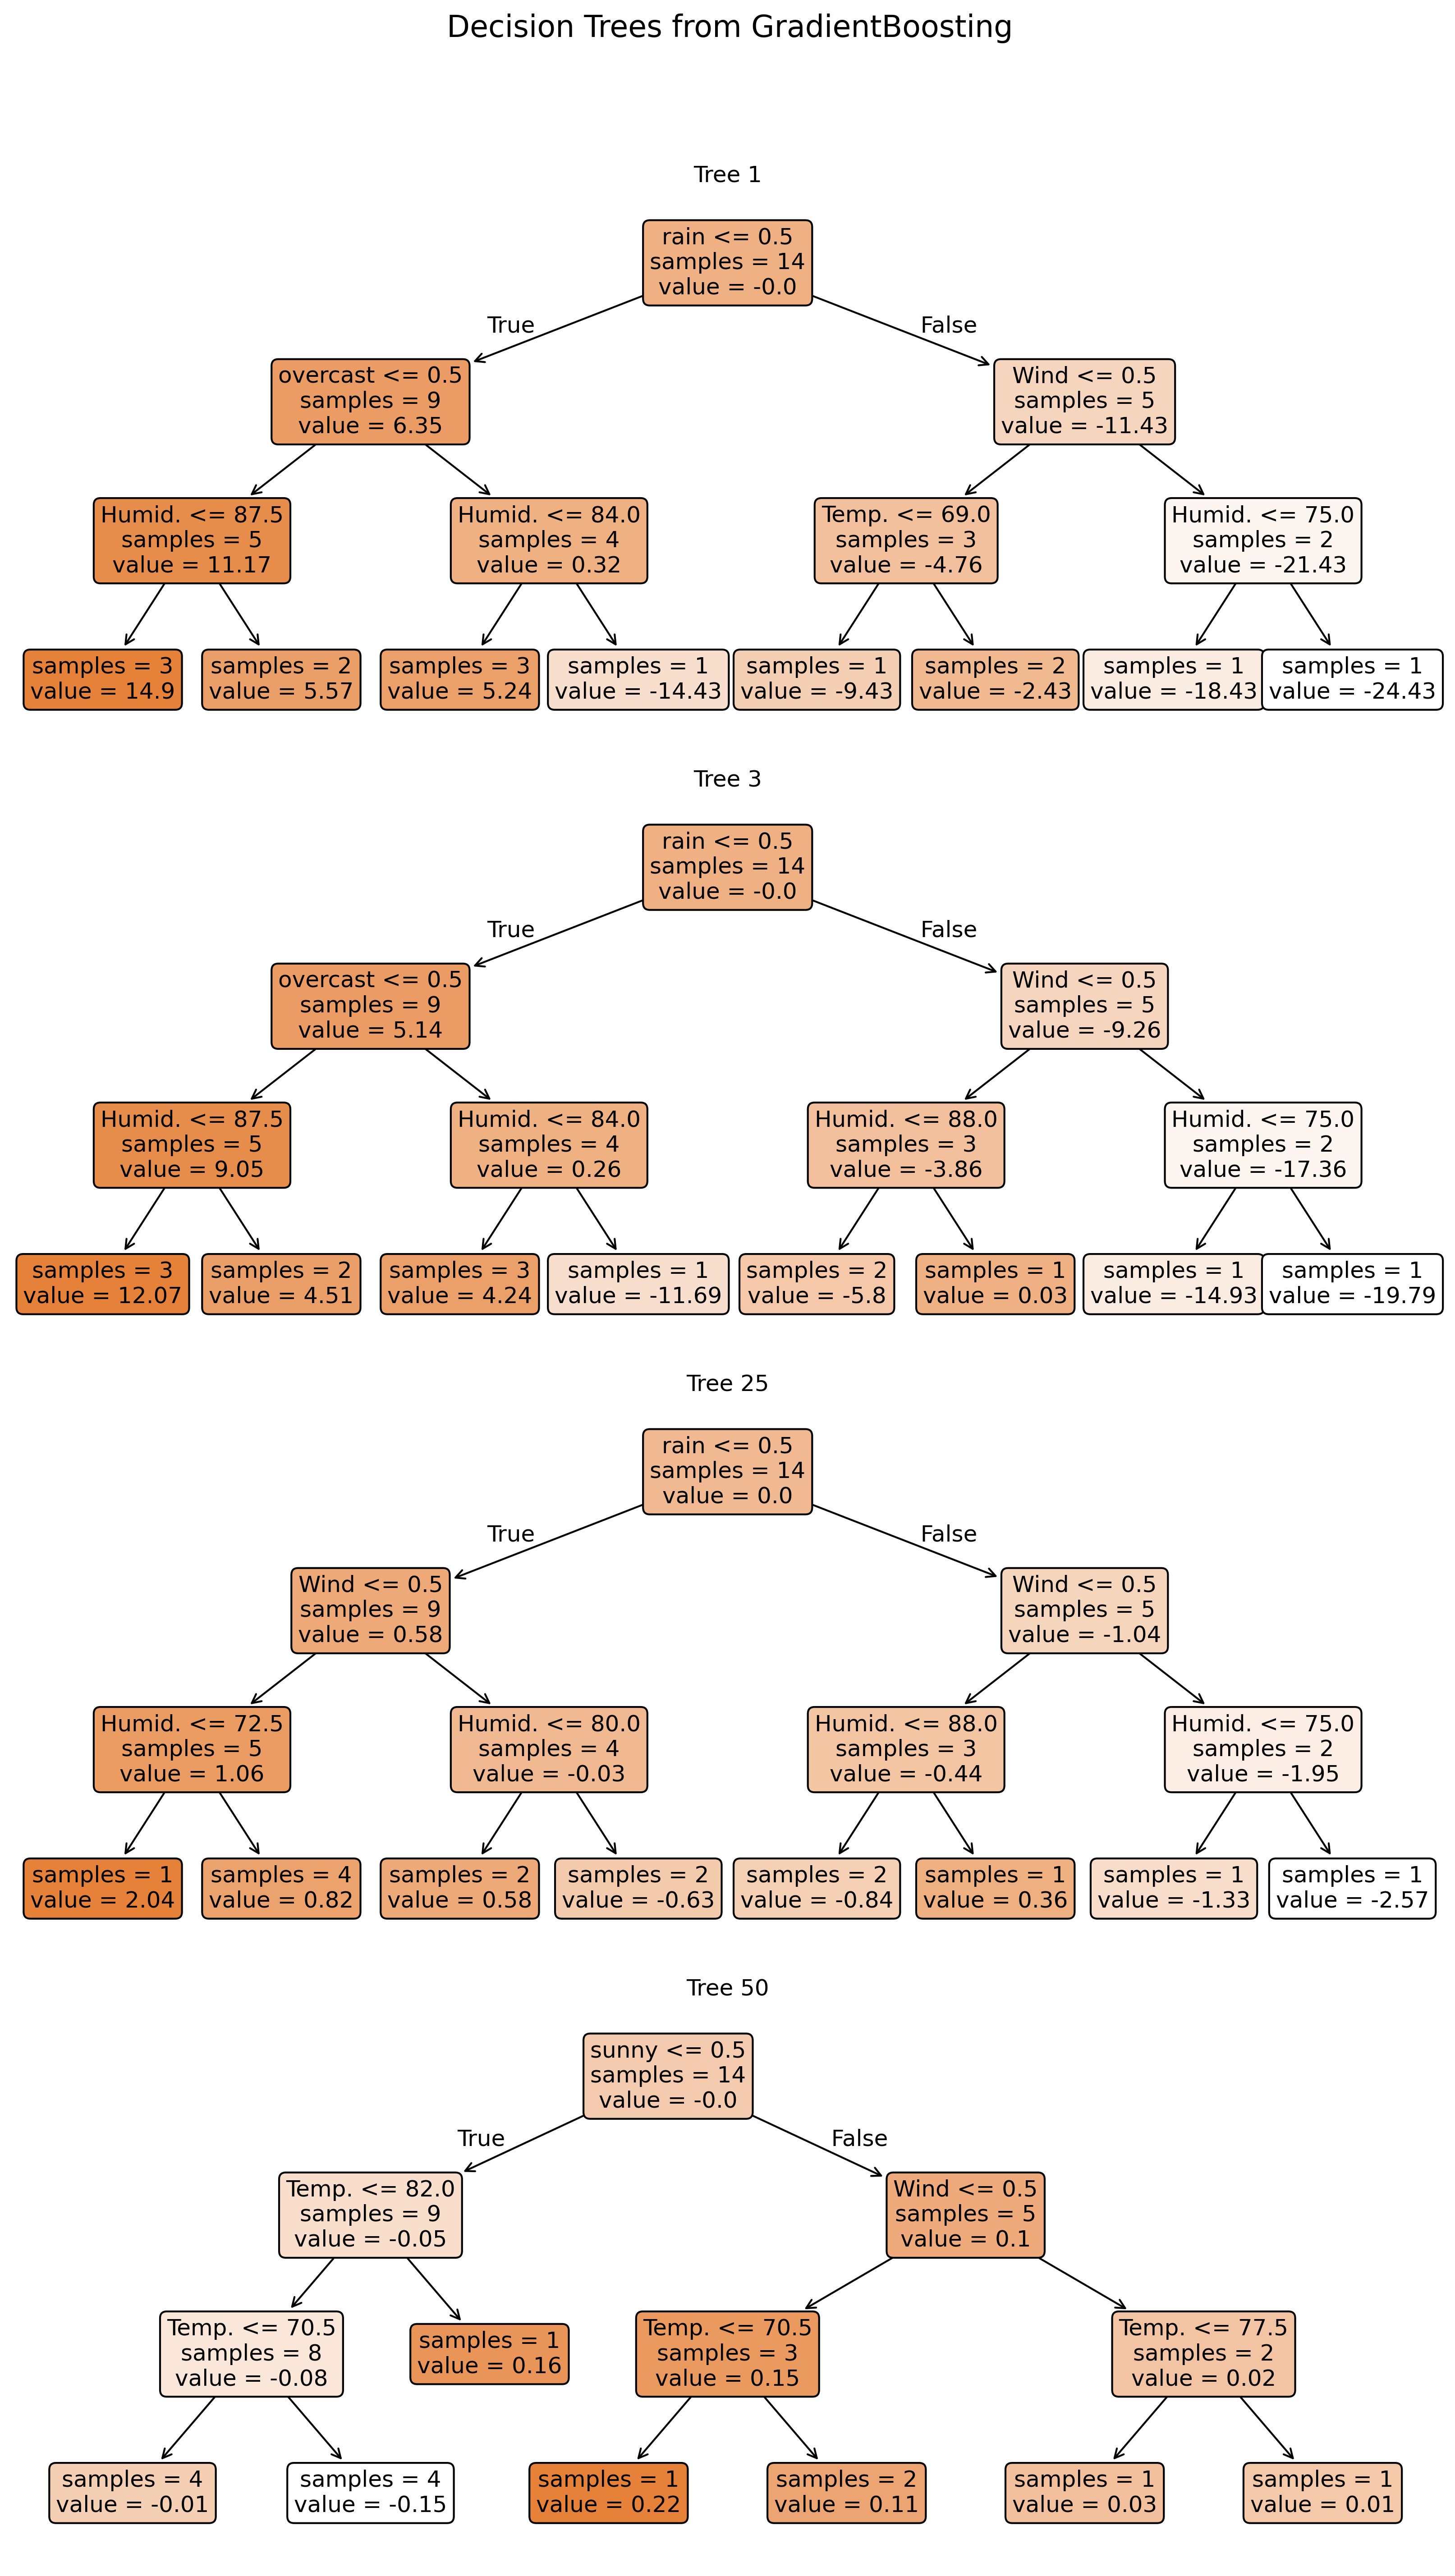

In [2]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# Train the model
clf = GradientBoostingRegressor(criterion='squared_error', learning_rate=0.1, random_state=42)
clf.fit(X_train, y_train)

# Plot trees 1, 2, 49, and 50
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 2, 24, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(clf.estimators_[tree_idx,0], 
              feature_names=X_train.columns,
              impurity=False,
              filled=True, 
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
# Get predictions
y_pred = clf.predict(X_test)

# Create DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results_df) # Display results DataFrame

# Calculate and display RMSE
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(f"nModel Accuracy: {rmse:.4f}")

    Actual  Predicted
14      33  38.992320
15      29  31.012362
16      25  32.991445
17      51  48.942655
18      41  46.819157
19      14  15.380151
20      34  26.808298
21      29  32.964361
22      49  49.265694
23      36  42.469100
24      57  52.881795
25      21  23.758305
26      23  28.147929
27      41  42.992096
nModel Accuracy: 4.6921
